# How does Relaxation affect DVA

In [31]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustnesss')[0], "EV_DVA_Robustnesss"))
from src.config_base import GeneralConfig

In [32]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [33]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

###### 

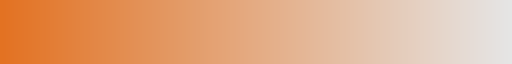

In [34]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 3))
tum_orange_cmap

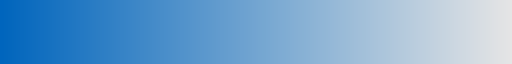

In [35]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 5))
tum_blue_cmap

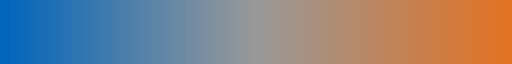

In [36]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.6)
colors = tum_cmap(np.linspace(1,0, 3))
color2 = colors[[1,0,2]]
tum_cmap

In [37]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [38]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [39]:
read_feather = ReadFeather()
#read_feather.set_filter_U(filter_func_preprocess_U)
#read_feather.set_filter_Q(filter_func_preprocess_Q)
#read_feather.set_filter_I(filter_func_preprocess_Q)

## Balacing 

In [40]:
%%capture
df_balancing = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_Balancing.feather"))

## CU Data

In [41]:
#read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

In [42]:
%%capture
df_vw_pre = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_JB_8A_CEE7_preRelax.feather"), calc_E = True, lower_voltage=365, upper_voltage=450) 
df_vw_mid = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxHighSOC.feather"), calc_E = True, lower_voltage=365, upper_voltage=450) 
df_vw_post = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxLowSOC.feather"), calc_E = True, lower_voltage=365, upper_voltage=450) 

In [43]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [44]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [45]:
dva_vw_pre, cap_vw_pre =dva_extractor.get_dva(time=df_vw_pre["time_h"], capacity=df_vw_pre["Q"], voltage=filter_func_preprocess_U(df_vw_pre["U"]),crop_cap_Ah=(0,180))
dva_vw_mid, cap_vw_mid =dva_extractor.get_dva(time=df_vw_mid["time_h"], capacity=df_vw_mid["Q"], voltage=filter_func_preprocess_U(df_vw_mid["U"]),crop_cap_Ah=(0,180))
dva_vw_post, cap_vw_post =dva_extractor.get_dva(time=df_vw_post["time_h"], capacity=df_vw_post["Q"], voltage=filter_func_preprocess_U(df_vw_post["U"]),crop_cap_Ah=(0,180))

In [46]:
%%capture
df_vw_pre_e = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_JB_8A_CEE7_preRelax.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_mid_e = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxHighSOC.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_post_e = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxLowSOC.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

## Plot

In [47]:
def plot_resting_time(axes, df):
    
    df_high_soc = df[1300:38850].copy()
    df_high_soc.time_h = (df_high_soc.time_h-df_high_soc.time_h.iloc[0])/24
    df_low_soc = df[154000:660000].copy()
    df_low_soc.time_h = (df_low_soc.time_h-df_low_soc.time_h.iloc[0])/24
    #print(df_low_soc.SOC.mean())
    color_ind =[0,1,2]
    axes.plot(df_high_soc.time_h+0.2,df_high_soc.U-60,color=colors[color_ind[0]],linewidth=2) # max ylim voltage before shift 460V
    axes.plot(df_low_soc.time_h+0.2,df_low_soc.U,color=colors[color_ind[2]],linewidth=2)
    
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlabel(r"Relaxation duration in days",fontsize=9)
    axes.set_xlim([0,21])
    tick_positions = np.array([0,7,14,21])
    axes.set_xticks(tick_positions)
    axes.set_ylim([370,395])
    tick_positions = np.array([370,375,380,385,390,395])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([1,2,3,4,5,6,8,9,10,11,12,13,15,16,17,18,19,20]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.set_yticklabels([370,375,445,450,455,460])
    for k, spine in axes.spines.items():  #ax.spines is a dictionary
        spine.set_zorder(1)
    axes.annotate(text="       ",
                          xy=(-1,377.5),
                          horizontalalignment="left",
                          verticalalignment="center",
                          fontsize=5,color="k",rotation=0,annotation_clip=False,
                    bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=1),zorder=2)

    axes.annotate(text="$||$",
                          xy=(0.2,377.5),
                          horizontalalignment="center",
                          verticalalignment="center",
                          fontsize=10,color="k",rotation=90,zorder=3)


    axes.annotate(text="       ",
                          xy=(20.8,377.5),
                          horizontalalignment="left",
                          verticalalignment="center",
                          fontsize=5,color="k",rotation=0,annotation_clip=False,
                    bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=1),zorder=2)

    axes.annotate(text="$||$",
                          xy=(21.2,377.5),
                          horizontalalignment="center",
                          verticalalignment="center",annotation_clip=False,
                          fontsize=10,color="k",rotation=90,zorder=3)

    # close up 1
    axins = axes.inset_axes([3, 380.5,6,7.1],transform = axes.transData) # [x0, y0, width, height][3.5, 376,6,6]
    axins.plot(df_high_soc.time_h+0.2,df_high_soc.U-60,color=colors[color_ind[0]],linewidth=2)
    # subregion of the original image
    x1, x2, y1, y2 = 0.15, 1.7, 387.5, 392.5
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    #axins.annotate(text='A', xy=(0.2,391.1), xytext=(0.2,391.1),fontsize=9)
    return axes

<Axes: xlabel='Relaxation duration in days', ylabel='Voltage in V'>

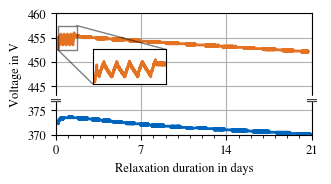

In [48]:
fig, axes= plt.subplots(1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))
plot_resting_time(axes, df_balancing)

In [49]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [50]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [51]:
def plot_dva_vw(axes,
                  lst_cap, lst_dva,df):
    color_ind =[0,1,2]
    Q_nom = 78*2
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)

    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,162])
    tick_positions = np.array([0,0.5,1,1.5])*108
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)
    
    twiny = axes.twiny() 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*df.U.mean()/1000:.0f}" for x in tick_positions])
    twiny.set_xlabel(r"Charged energy in kWh",fontsize=9)
    #twiny.set_xticklabels([])
    axes.annotate(text='A', xy=(12,77), xytext=(20,58),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    #insert axes left
    axins = axes.inset_axes([35, 73,32,80],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        axins.scatter(xpos,ypos,marker="d",color=colors[color_ind[ind]],edgecolors="k",zorder=4)
    
    # subregion of the original image
    x1, x2, y1, y2 = 76, 94, 95, 162
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    
    axins.annotate(text='B', xy=(76.5,150), xytext=(76.5,150),fontsize=9)


    #insert axes right
    axins = axes.inset_axes([100, 15,40,60],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xcap, yDVA = find_H2_peak(cap = lst_cap[ind],dva = lst_dva[ind]*Q_nom,Q_min=110,Q_max=150)
        maxDVA = np.argmax(yDVA)
        axins.scatter(xcap[maxDVA],yDVA[maxDVA],marker="o",color=colors[color_ind[ind]],edgecolors="k",zorder=4)
    # # outlier
    # xpos, ypos = find_max_min(lst_cap[1], lst_dva[1]*Q_nom, xmin=78, xmax=104, maximum=True)
    # axins.scatter(xpos,ypos,marker="d",color=colors[color_ind[1]],edgecolors="gray",zorder=2,)
    # subregion of the original image
    x1, x2, y1, y2 = 112, 142, 110, 130
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    # axins.annotate(text='', xy=(87,142), xytext=(87,98),fontsize=9,verticalalignment="bottom",
    #                   arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    axins.annotate(text='C', xy=(112.35,125), xytext=(112.35,125),fontsize=9)
    
    return axes

<Axes: xlabel='Charged capacity in Ah', ylabel='$Q_{N}\\cdot \\frac{dU}{dQ}$ in V'>

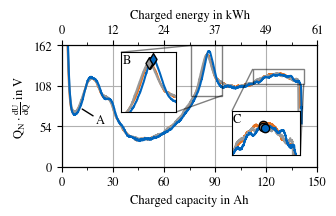

In [52]:
fig, axes= plt.subplots(1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))
plot_dva_vw(axes, lst_cap = [cap_vw_pre,cap_vw_mid,cap_vw_post], lst_dva = [dva_vw_pre,dva_vw_mid,dva_vw_post],df = df_vw_pre)

In [53]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=color2,remove_tick_ind=None):
    
    axes.spines['top'].set_color('white')
    axes.spines['left'].set_color('none')
    axes.spines['right'].set_color('white')
    
    width = 0.5 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=9,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    #axes.set_xticks(x)
    #tick_labels = [label for label in X]
    #axes.set_xticklabels(tick_labels,rotation=45,fontsize=7,ha='right',va="top",rotation_mode="anchor")
    axes.set_xlim([-0.5,1.5])
    axes.set_ylim([70,105])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='white',length=0)
    #axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.set_ylabel(r"$SOH_E$ in %",fontsize=9)
    axes.yaxis.set_label_coords(0.05,0.5)
    axes.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axes.tick_params('x',  top=False, labeltop=False,bottom=False, labelbottom=False)
    #axes.set_title(r"$SOH_E$ in %",fontsize=6, y=0.65)
    return axes

C:\Users\Philip Bilfinger\AppData\Local\Temp\ipykernel_26628\1327360483.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


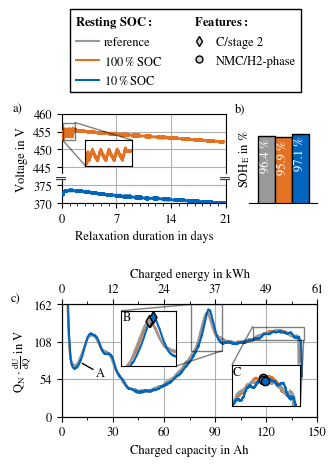

In [54]:
n_rows = 2
heigth = 5 #cm
fig = plt.figure(figsize=(VisualizationConfig.columnwidth_in_in.value,
                                n_rows * cm2inch(heigth)),constrained_layout=False)

gs = fig.add_gridspec(2, 2,hspace=1,height_ratios=[0.8,1],width_ratios=[1.2,0.5])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0:2])

ax1 = plot_resting_time(ax1, df_balancing)
E_nom_VW = 58
ax2 = bar_plot_soh(ax2, X=[0,1,2],y1 = np.hstack(np.array([df_vw_pre_e.E.max(),df_vw_mid_e.E.max(),df_vw_post_e.E.max()])/E_nom_VW*100))
ax3 = plot_dva_vw(ax3, lst_cap = [cap_vw_pre,cap_vw_mid,cap_vw_post], lst_dva = [dva_vw_pre,dva_vw_mid,dva_vw_post],df = df_vw_pre)


plt.tight_layout()

ax1.text(-0.3, 1.05, 'a)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax1.transAxes)
ax2.text(-0.2, 1.05, 'b)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax2.transAxes)
ax3.text(-0.2, 1.05, 'c)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax3.transAxes)
# legend
handles, labels =ax1.get_legend_handles_labels()  
line1 = plt.hlines(-7,0,1,label="reference", color=colors[1])
line2 = plt.hlines(-7,0,1,label="$100\, \%\, SOC$", color=colors[0])
line3 = plt.hlines(-7,0,1,label="$10\, \%\, SOC$", color=colors[2])

marker1 =mlines.Line2D([], [], color='lightgray', marker='d',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'C/stage 2')
marker2 =  mlines.Line2D([], [], color='lightgray', marker='o',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'NMC/H2-phase')
lgd=fig.legend(handles=[line1,line2,line3,marker1,marker2],loc="center",fontsize=9,ncols=2,handletextpad=0.3,
            framealpha =1 , fancybox=False,columnspacing=2,edgecolor="black",bbox_to_anchor=(0.5,1.04),title=r"$\bf{Resting\ SOC:}$"+"\t\t"+r" $\bf{Features:}$",alignment='left')
#fig.tight_layout()
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"05-FIG-Relaxation.pdf"), bbox_inches='tight') 
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"05-FIG-Relaxation.png"),dpi=300, pad_inches = 0) 